In [1]:
# Importing modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
data = pd.read_csv("vgsales.csv")
data.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


## Phase 1 : Histogram

### What a Histogram Shows

A histogram shows the **distribution of a numerical variable**.

In simple terms it answers:

* Where are most values concentrated?
* Is the data skewed?
* Are there long tails?
* Are there multiple peaks?

Since you already saw skewness in `describe()`, this will **confirm it visually**.

---

### How Histogram Works (Concept)

Histogram divides the data into **bins (ranges)**.

Example:

Global sales might be divided into ranges like:

```
0 - 1 million
1 - 2 million
2 - 3 million
3 - 4 million
...
```

Then it counts how many games fall into each bin.

The bar height = **frequency**.

So you're basically seeing **how values are distributed**.

---

### Your First Histogram

```python
import matplotlib.pyplot as plt

plt.hist(df['Global_Sales'])
plt.show()
```

That’s the simplest possible histogram.

---

(array([1.6526e+04, 5.1000e+01, 1.2000e+01, 7.0000e+00, 1.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([ 0.   ,  2.902,  5.804,  8.706, 11.608, 14.51 , 17.412, 20.314,
        23.216, 26.118, 29.02 ]),
 <BarContainer object of 10 artists>)

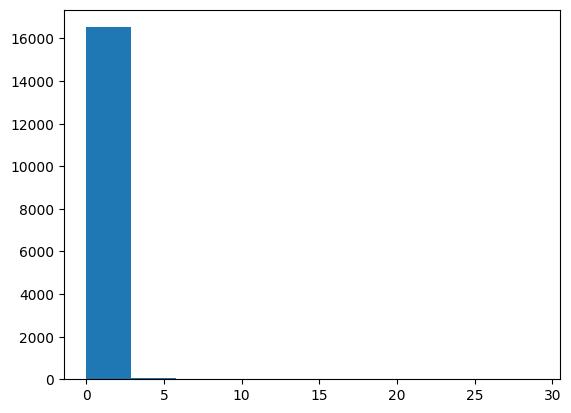

In [5]:
plt.hist(data["EU_Sales"])

### Now Improve It Slightly

Always add labels.

```python
plt.hist(df['Global_Sales'], bins=30)

plt.title("Distribution of Global Game Sales")
plt.xlabel("Global Sales (Millions)")
plt.ylabel("Number of Games")

plt.show()
```

### Why `bins=30`?

Bins control how many ranges we split data into.

Too few bins → oversimplified
Too many bins → noisy

20–40 bins usually works well.

---

### What You Should Observe

When you run this on your dataset you will likely see:

* A **very tall bar near 0**
* Bars quickly decreasing
* A **long tail on the right**

This visually confirms what you discovered earlier:

> The dataset is strongly right-skewed.

Most games sell very little.

Few games sell extremely high.

---

### A Very Important Habit

Never just plot.

Always ask:

1️. Where are most values concentrated? \
2️. Is the distribution symmetric or skewed? \
3️. Are there extreme values? \
4️. Is the tail long?

This is the difference between **plotting** and **analysis**.

---


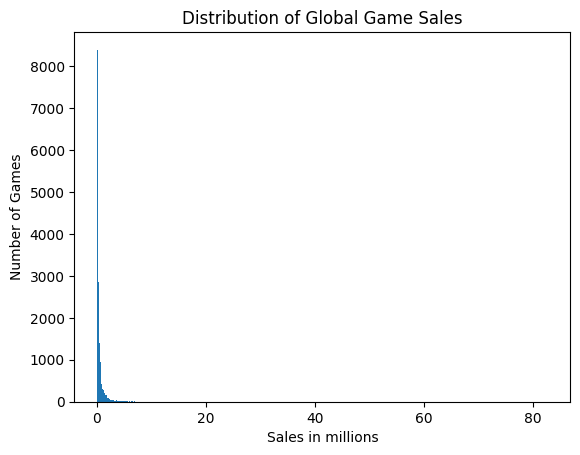

In [8]:
# Adding the x label and y label
plt.hist(data["Global_Sales"], bins=500)
plt.title("Distribution of Global Game Sales")
plt.xlabel("Sales in millions")
plt.ylabel("Number of Games")
plt.show()

## Phase 1: Box Plot

### What a Box Plot Shows

A box plot summarizes a distribution using **five key statistics**:

* Minimum
* Q1 (25th percentile)
* Median (50th percentile)
* Q3 (75th percentile)
* Maximum

It also highlights **outliers**.

So instead of seeing the whole distribution like histogram, you see the **core structure of the data**.

---

### Visual Structure of a Boxplot

```
Min ────|────[ Q1 | Median | Q3 ]────|──── Max
```

Components:

* **Box start → Q1**
* **Box center line → Median**
* **Box end → Q3**
* **Whiskers → range of normal values**
* **Dots outside → outliers**

---

#### Why Boxplots Are Powerful

They instantly show:

* Data spread
* Skewness
* Outliers
* Median position

For your dataset this will clearly show the **blockbuster games** as outliers.

---

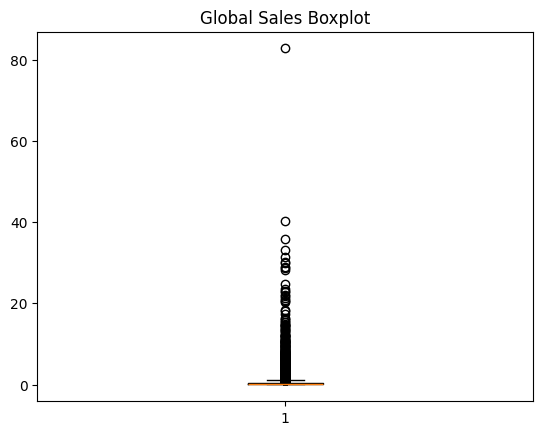

In [10]:
plt.boxplot(data["Global_Sales"])
plt.title("Global Sales Boxplot")
plt.show()

### Interpretation

Here’s the **clean summary of what the boxplot shows**:

#### Most Games Sell Very Little

The box (middle 50% of the data) is extremely close to zero.
This means **most games have very low global sales**, generally below about **0.5 million**.

---

#### The Distribution is Strongly Right-Skewed

The median is near the bottom of the box and the values stretch far upward.
This indicates a **long right tail**, meaning a few games have extremely high sales.

---

#### Many Outliers Exist

There are a large number of points above the whiskers.
These represent **games that sold far more than the typical game**.

These are the blockbuster titles.

---

#### Sales are Highly Uneven

Most games perform poorly, while **a very small number achieve massive success**.

This creates a **long-tail distribution**, which is common in industries like games, movies, and music.

---

#### Extreme Maximum Values

Some outliers reach very high sales (around **80+ million**), which are drastically larger than the median sales (~0.17 million).

This shows **huge variability in game performance**.

---

### Important Concept — IQR

Boxplots rely on something called **Interquartile Range (IQR)**.

```
IQR = Q3 − Q1
```

Outliers are detected using:

```
Lower bound = Q1 - 1.5 × IQR
Upper bound = Q3 + 1.5 × IQR
```

Any value outside this range appears as **a dot**.

This is the standard statistical method for detecting outliers.

---

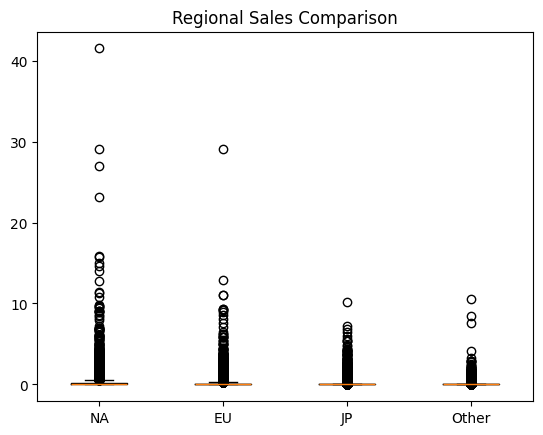

In [13]:
# you can compare regional sales too

plt.boxplot([
    data['NA_Sales'],
    data['EU_Sales'],
    data['JP_Sales'],
    data['Other_Sales']
])

plt.xticks([1,2,3,4], ['NA', 'EU', 'JP', 'Other'])

plt.title("Regional Sales Comparison")

plt.show()

## Phase 1: Bar Plot

### What a Bar Plot Shows

A bar plot answers questions like:

* Which category performs better?
* Which group has the highest value?
* How do categories compare?

In your dataset good examples are:

* Sales by **region**
* Sales by **genre**
* Sales by **platform**

---


<BarContainer object of 4 artists>

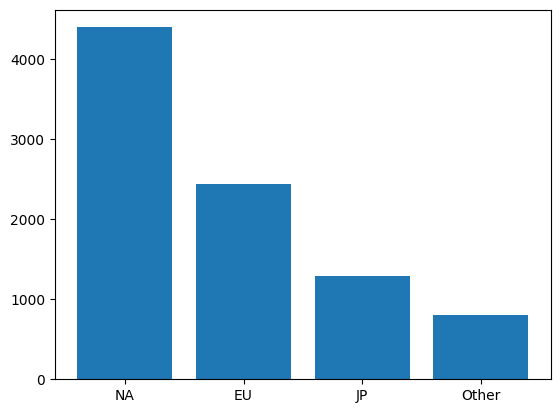

In [15]:
regions = ["NA","EU","JP","Other"] # x axis

sales = [data["NA_Sales"].sum(), data["EU_Sales"].sum(), data["JP_Sales"].sum(), data["Other_Sales"].sum()] # y axis

plt.bar(regions, sales)



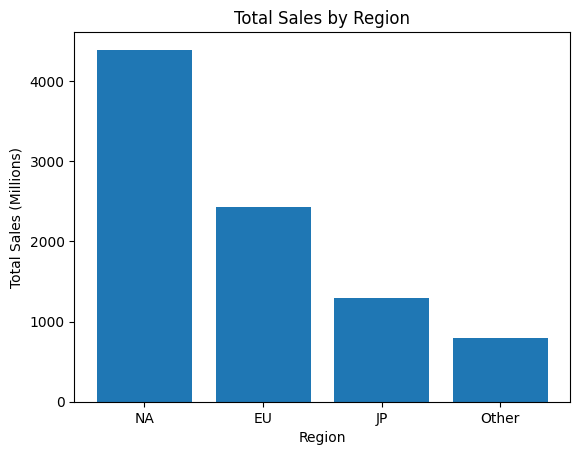

In [17]:
egions = ['NA', 'EU', 'JP', 'Other']

sales = [
    data['NA_Sales'].sum(),
    data['EU_Sales'].sum(),
    data['JP_Sales'].sum(),
    data['Other_Sales'].sum()
]

plt.bar(regions, sales)

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales (Millions)")

plt.show()

### What this shows

Each bar = **total sales for that region**.

This answers questions like:

* Which region generates most revenue?
* Which region is smallest?

---

### What You Should Expect

Usually the order will be roughly:

```
North America > Europe > Japan > Other
```

This means:

* NA dominates the market
* EU second biggest
* Japan smaller but still important

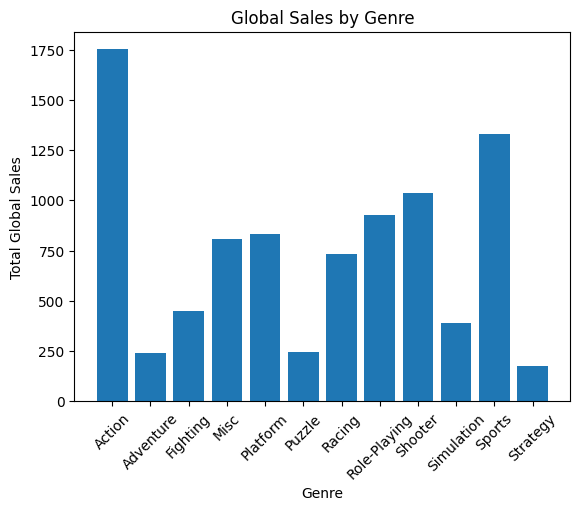

In [ ]:
# X axis
genres = data["Genre"].unique()

#y axis
sales = data.groupby("Genre")["Global_Sales"].sum()

# plt.bar(genres, sales.values) 
# or you can also do
plt.bar(sales.index, sales.values)

plt.xticks(rotation=45) # handles rotation of labels on x axis
plt.title("Global Sales by Genre")
plt.xlabel("Genre")
plt.ylabel("Total Global Sales")

plt.show() # avoids extra info printing

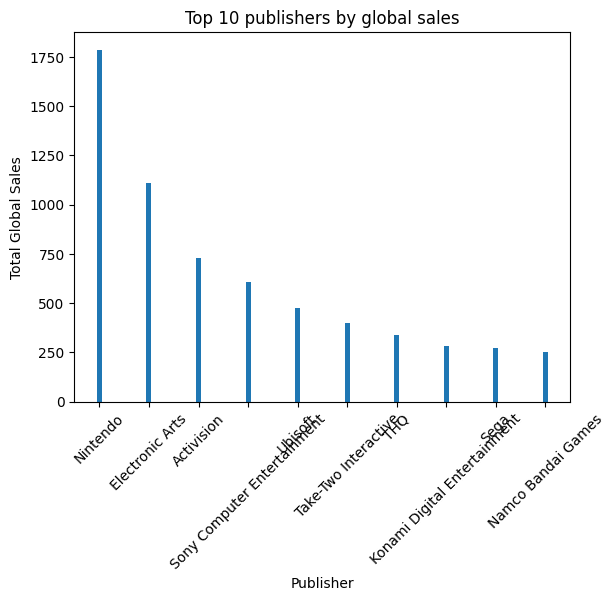

In [28]:
# Top 10 publishers by global sales

sales = data.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False).head(10)

plt.bar(sales.index, sales.values, width=0.1)

plt.xticks(rotation=45) 
plt.title("Top 10 publishers by global sales")
plt.xlabel("Publisher")
plt.ylabel("Total Global Sales")

plt.show() # avoids extra info printing


#### Important Rule for Bar Plots

Bar plots require **aggregated values**.

Never do this:

```
plt.bar(df['Genre'], df['Global_Sales'])
```

That creates **thousands of bars** and is useless.

Instead use:

```
groupby
sum
mean
count
```

---


## Phase 1: Scatter Plot

### What a Scatter Plot Shows

A scatter plot shows how **two numerical variables relate to each other**.

Each dot represents **one observation (one game in your dataset)**.

Example:

```text
x-axis → NA_Sales
y-axis → Global_Sales
```

Each point = one game.

So if a game sold:

```
NA = 2M
Global = 5M
```

You will see a dot at **(2,5)**.

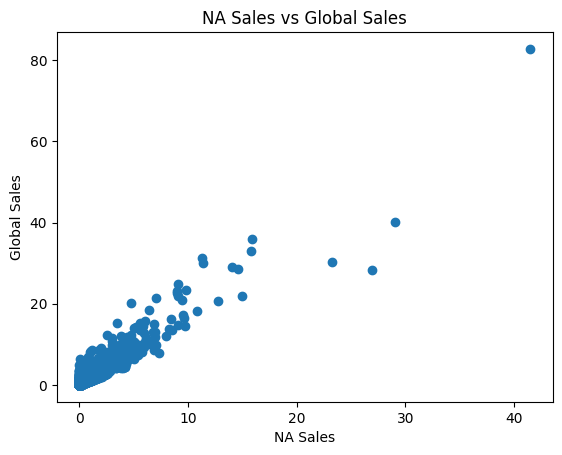

In [35]:
plt.scatter(data['NA_Sales'], data['Global_Sales'])

plt.title("NA Sales vs Global Sales")
plt.xlabel("NA Sales")
plt.ylabel("Global Sales")

plt.show()

### What You Should Expect to See

You should see **points forming a diagonal trend upward**.

Why?

Because:

```
Global Sales = NA + EU + JP + Other
```

So when NA increases, global sales usually increase too.

That creates **positive correlation**.

---

### How to Interpret a Scatter Plot

When looking at scatter plots ask:

#### Is there a pattern?

* Upward slope → positive relationship
* Downward slope → negative relationship
* Random cloud → no relationship

---

#### Are there clusters?

Example:

* Many games near (0,0)
* Few games far away

This means most games sell little.

---

#### Are there extreme points?

You may see dots far from the rest.

Those are **blockbuster games** again.

---


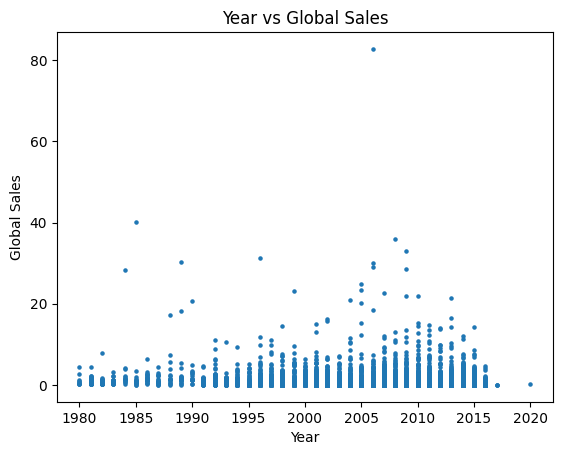

In [ ]:
plt.scatter(data['Year'], data['Global_Sales'], s=5) # you can adjust the marker size

plt.title("Year vs Global Sales")
plt.xlabel("Year")
plt.ylabel("Global Sales")

plt.show()

## Phase 1 : Line Plot

In [39]:
games_per_year = data["Year"].value_counts().sort_values(ascending=True)

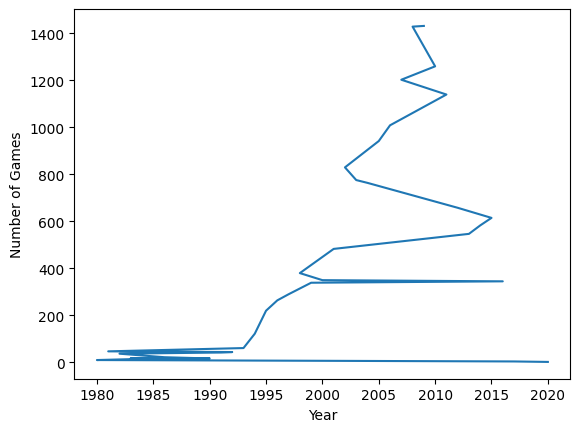

In [40]:
plt.plot(games_per_year)
plt.xlabel("Year")
plt.ylabel("Number of Games")

plt.show()

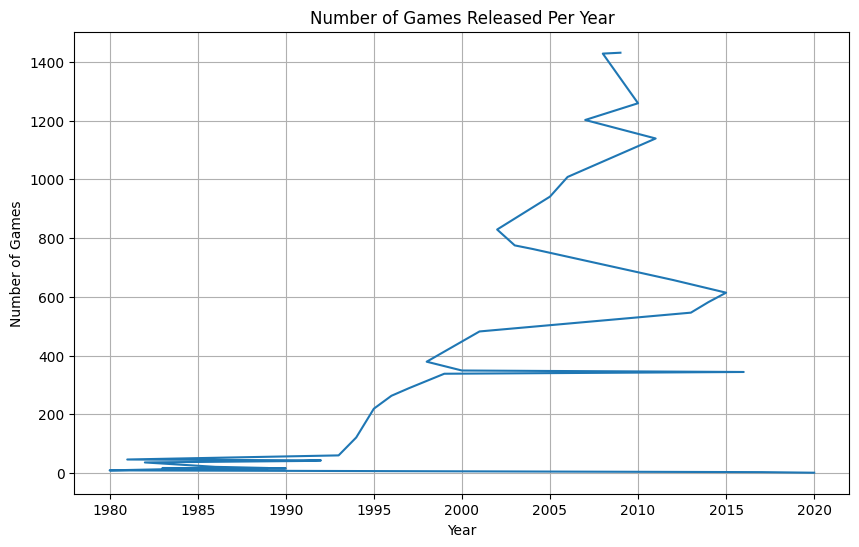

In [41]:
plt.figure(figsize=(10,6))

plt.plot(games_per_year)

plt.title("Number of Games Released Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Games")

plt.grid()

plt.show()

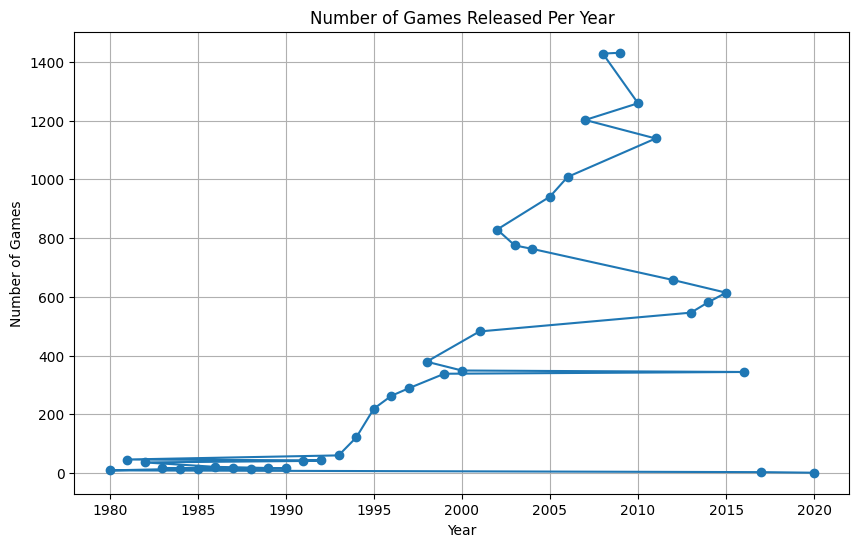

In [42]:
plt.figure(figsize=(10,6))

plt.plot(games_per_year, marker='o')

plt.title("Number of Games Released Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Games")

plt.grid()

plt.show()

### What This Plot Shows

You will see something like:

1. Slow growth in early years

2. Rapid rise around 2005–2010

3. Decline after that

This reflects the console boom era.

Industry exploded during:

**Wii Sports era**

**Grand Theft Auto V era**

Then the industry shifted toward digital distribution and mobile games, which this dataset may not capture well.

### What You Should Be Comfortable With Now

You now know the 5 essential matplotlib plots:

**Histogram → distribution**

**Boxplot → outliers**

**Bar plot → category comparison**

**Scatter plot → relationships**

**Line plot → trends**